# VISION TASK
# Image Classification with Convolutional Neural Network.

### Mounting Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Unzipping the dataset

In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/AI_ML/2408388_Anuska_G.C._AI_Assignment/Vision_Task/insect_classification.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset extracted successfully!")


Dataset extracted successfully!


### Setting the Paths for train and test folder

In [ ]:
# Path to the training images folder
train_dir = '/content/dataset/Insect Classification/train'
# Path to the test images folder
test_dir  = '/content/dataset/Insect Classification/test'

### Importing necessary libraries

In [ ]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import tensorflow as tf

from PIL import Image, UnidentifiedImageError
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    BatchNormalization, Dropout, Activation,
    GlobalAveragePooling2D
)
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

print('All libraries imported successfully!')

All libraries imported successfully!


## Part A: Designing and Analyzing Convolutional Neural Networks from Scratch.


### Viewing the class structure of the dataset

In [ ]:
# sorted() ensures a consistent alphabetical ordering every run
class_names = sorted(os.listdir(train_dir))
# Count the total number of distinct insect classes
num_classes = len(class_names)
print(f'Classes ({num_classes} total): {class_names}')

Classes (9 total): ['aphids', 'armyworm', 'beetle', 'bollworm', 'grasshopper', 'mites', 'mosquito', 'sawfly', 'stem_borer']


### Test and Train Dataset Status


========================================================================================== DATASET SUMMARY ==========================================================================================


,Class,Training Count,% of total
0,aphids,266,11.9%
1,armyworm,223,10.0%
2,beetle,291,13.0%
3,bollworm,245,11.0%
4,grasshopper,277,12.4%
5,mites,254,11.4%
6,mosquito,295,13.2%
7,sawfly,200,9.0%
8,stem_borer,181,8.1%
,Class,Test Count,% of total



Training Status: Balanced
Test Status: Balanced


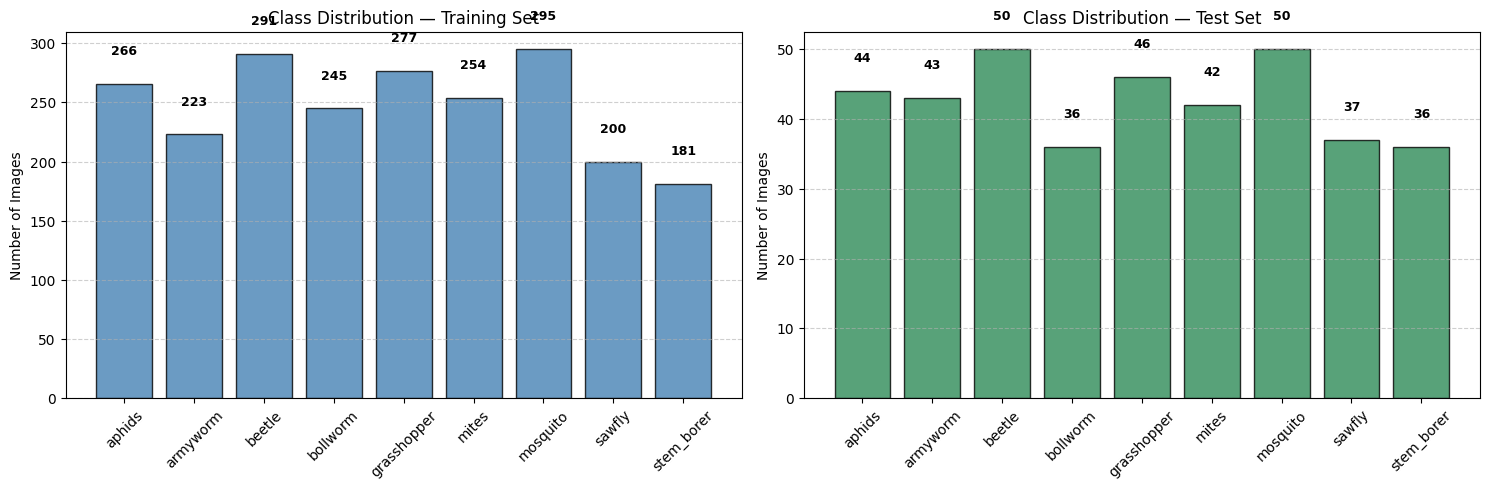

In [ ]:
import pandas as pd
from IPython.display import display, HTML
import matplotlib.pyplot as plt

def get_distribution_df(data_dir, set_name):
    """
    Counts the number of images per class in a dataset directory.
    Returns a DataFrame, a counts dict, and the total image count.
    """
    counts = {}  # Dictionary to hold {class_name: image_count}

    # List only subdirectories (each subdirectory = one class)
    classes = sorted([d for d in os.listdir(data_dir)
                      if os.path.isdir(os.path.join(data_dir, d))])

    for cls in classes:
        path = os.path.join(data_dir, cls)  # Full path to the class folder
        # Count only valid image files (ignore hidden files or non-images)
        imgs = [f for f in os.listdir(path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        counts[cls] = len(imgs)  # Store image count for this class

    total = sum(counts.values())  # Total images across all classes

    # Build a DataFrame with class name, count, and percentage columns
    df = pd.DataFrame(list(counts.items()), columns=['Class', f'{set_name} Count'])
    df['% of total'] = df[f'{set_name} Count'].apply(
        lambda x: f"{(x / total * 100):.1f}%" if total > 0 else "0%"
    )
    return df, counts, total

# 1. Get Data
df_train, counts_train, total_train = get_distribution_df(train_dir, 'Training')
df_test, counts_test, total_test = get_distribution_df(test_dir, 'Test')

# 2. Display Tables Side-by-Side (As before)
print("\n" + "="*90 + " DATASET SUMMARY " + "="*90)
t1 = df_train.style.set_table_attributes("style='display:inline'").set_caption("Training Set")
t2 = df_test.style.set_table_attributes("style='display:inline'").set_caption("Test Set")
display(HTML(t1._repr_html_() + " &nbsp; " * 120 + t2._repr_html_()))

# 3. Imbalance Status
for name, counts, total in [('\nTraining', counts_train, total_train), ('Test', counts_test, total_test)]:
    if total > 0:
        ratio = max(counts.values()) / min(counts.values())
        status = 'Balanced' if ratio < 2 else f'Imbalanced (Ratio: {ratio:.2f})'
        print(f"{name} Status: {status}")

# 4. Display Figures Horizontally
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

def draw_bars(ax, counts, total, set_name, color):
    bars = ax.bar(counts.keys(), counts.values(), color=color, edgecolor='black', alpha=0.8)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + (total * 0.01),
                str(int(h)), ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(f'Class Distribution — {set_name} Set', fontsize=12)
    ax.set_ylabel('Number of Images')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

draw_bars(ax1, counts_train, total_train, 'Training', 'steelblue')
draw_bars(ax2, counts_test, total_test, 'Test', 'seagreen')

plt.tight_layout()

### Checking for corrupted Images

In [ ]:
# List to collect paths of any corrupted images found during scanning
corrupted_images = []

# Iterate over both the training and test directories
for split_dir in [train_dir, test_dir]:
    # Iterate over each class folder inside the split directory
    for class_name in os.listdir(split_dir):
        class_path = os.path.join(split_dir, class_name)

        # Skip any non-directory entries (e.g. hidden system files)
        if not os.path.isdir(class_path):
            continue

        # Iterate over every image file inside the class folder
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                # Open the image and call verify() to check file integrity
                # verify() is faster than fully decoding the image —
                # it only reads headers and structural metadata
                with Image.open(img_path) as img:
                    img.verify()

            # Catch three types of file corruption:
            # IOError: file cannot be opened or read
            # UnidentifiedImageError: file format not recognised by PIL
            # SyntaxError: file header is malformed / partially written
            except (IOError, UnidentifiedImageError, SyntaxError):
                corrupted_images.append(img_path)  # Record the bad file
                os.remove(img_path)                 # Delete it so it won't cause training errors
                print(f'Removed corrupted image: {img_path}')

# Summary after scanning
if corrupted_images:
    print(f'\nTotal corrupted images removed: {len(corrupted_images)}')
else:
    # Clean dataset — no files were removed
    print('No corrupted images found. Dataset is clean.')

Removed corrupted image: /content/dataset/Insect Classification/train/stem_borer/jpg_9 - Copy (2).jpg
Removed corrupted image: /content/dataset/Insect Classification/train/stem_borer/jpg_11.jpg
Removed corrupted image: /content/dataset/Insect Classification/train/stem_borer/jpg_65 - Copy (2).jpg
Removed corrupted image: /content/dataset/Insect Classification/train/stem_borer/jpg_1.jpg
Removed corrupted image: /content/dataset/Insect Classification/train/stem_borer/jpg_97.jpg
Removed corrupted image: /content/dataset/Insect Classification/train/stem_borer/jpg_27 - Copy (2).jpg
Removed corrupted image: /content/dataset/Insect Classification/train/stem_borer/jpg_65 - Copy (2) - Copy.jpg
Removed corrupted image: /content/dataset/Insect Classification/train/stem_borer/jpg_49 - Copy.jpg
Removed corrupted image: /content/dataset/Insect Classification/train/stem_borer/jpg_38.jpg
Removed corrupted image: /content/dataset/Insect Classification/train/stem_borer/jpg_56 - Copy.jpg
Removed corrupted

### Viewing the sample Images

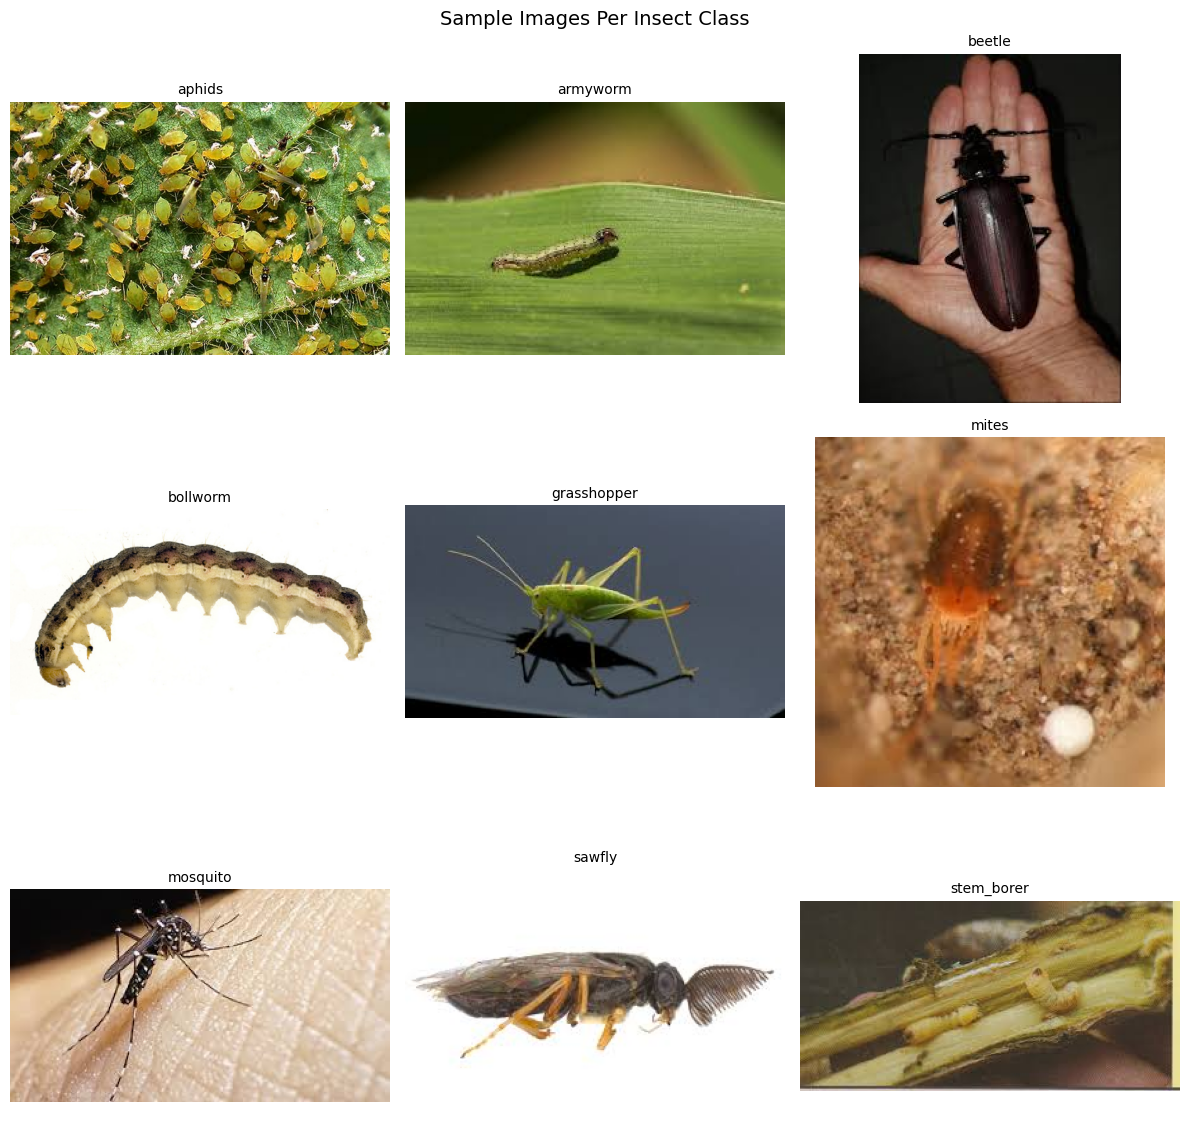

In [ ]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Lists to hold the file paths and corresponding class names of selected images
selected_images, selected_labels = [], []

# Select up to 9 classes (for 3x3 grid)
max_classes = 9
selected_classes = class_names[:max_classes]  # Take first 9 classes

for class_name in selected_classes:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png','.jpg','.jpeg'))]
        if images:
            selected_images.append(os.path.join(class_path, random.choice(images)))
            selected_labels.append(class_name)

# 3x3 grid
cols = 3
rows = 3
fig, axes = plt.subplots(rows, cols, figsize=(12, 12))

for i, ax in enumerate(axes.flat):
    if i < len(selected_images):
        ax.imshow(mpimg.imread(selected_images[i]))
        ax.set_title(selected_labels[i], fontsize=10)
        ax.axis('off')
    else:
        ax.axis('off')  # Hide empty subplots if less than 9 classes

plt.suptitle('Sample Images Per Insect Class', fontsize=14)
plt.tight_layout()


### Setting height, width and batch size

In [ ]:
IMG_HEIGHT = 128  # Target height for resizing images
IMG_WIDTH  = 128  # Target width for resizing images
BATCH_SIZE = 32   # Number of images in each batch during training/evaluation

# Print the configured image size, batch size, and number of classes for verification
print(f'Image size : {IMG_HEIGHT} x {IMG_WIDTH}')
print(f'Batch size : {BATCH_SIZE}')
print(f'Num classes: {num_classes}')

Image size : 128 x 128
Batch size : 32
Num classes: 9


### Splitting the dataset

In [ ]:
# 80% training, 20% validation
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='both',
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
)

# Load the test directory separately
# shuffle=False keeps images in a fixed order which is essential for matching
# predictions to true labels during evaluation
test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2111 files belonging to 9 classes.
Using 1689 files for training.
Using 422 files for validation.
Found 384 files belonging to 9 classes.


### Augmentation Layer

In [ ]:
# Define a list of augmentation layers to apply randomly during training.

data_augmentation_layers = [
    # RandomFlip('horizontal'): randomly mirrors images left-to-right (50% chance)
    # Insects can appear in either orientation, so this is a valid transformation
    layers.RandomFlip('horizontal'),

    # RandomRotation(0.15): randomly rotates images by up to ±15% of 360° (≈ ±54°)
    # Helps the model generalise to insects at different angles
    layers.RandomRotation(0.15),

    # RandomZoom(0.15): randomly zooms in or out by up to 15%
    # Simulates images taken at varying distances from the insect
    layers.RandomZoom(0.15),

    # RandomContrast(0.2): randomly adjusts image contrast by up to 20%
    # Helps the model handle lighting variations in the real world
    layers.RandomContrast(0.2),
]

def data_augmentation(images):
    """
    Applies all augmentation layers sequentially to a batch of images.
    training=True forces augmentation to run (layers behave differently
    at inference time — they pass images through unchanged by default).
    """
    for layer in data_augmentation_layers:
        images = layer(images, training=True)  # Apply each transform in sequence
    return images

print('Augmentation layers defined!')


Augmentation layers defined!


Visualizing Augmented Images

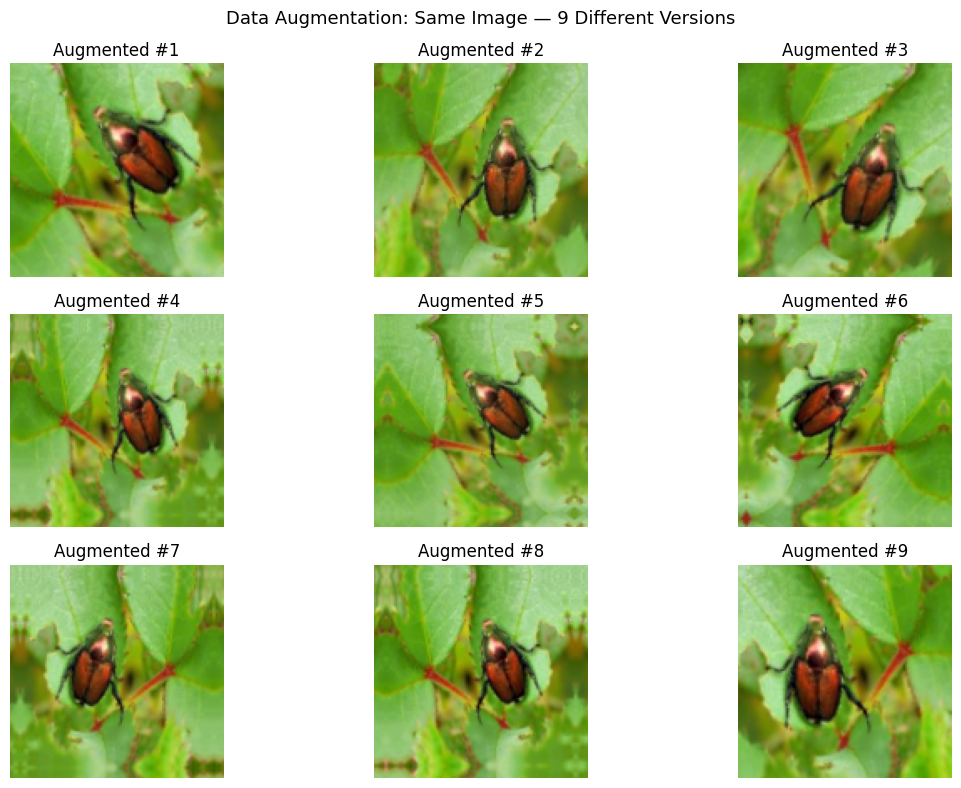

In [ ]:
# Create a figure to display 9 augmented versions of the same image
plt.figure(figsize=(12, 8))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented[0]).astype('uint8')) # uint8 range [0, 255] is required for imshow to render correctly
        plt.title(f'Augmented #{i+1}')
        plt.axis('off')
plt.suptitle('Data Augmentation: Same Image — 9 Different Versions', fontsize=13)
plt.tight_layout(); plt.show()

### Applying Augmentation and Optimizing Data Pipeline

In [ ]:
import tensorflow as tf

# Apply data augmentation to the training pipeline using .map()
# This runs augmentation on the CPU data pipeline BEFORE images reach the GPU.
# Reason: Augmentation layers like RandomRotation use ImageProjectiveTransformV3 under the hood, which can cause XLA GPU JIT compilation crashes in some TF versions.
# Running it on the CPU pipeline avoids this known issue.
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x), y),  # Apply augmentation to images only, not labels
    num_parallel_calls=tf.data.AUTOTUNE       # Use as many CPU threads as available for speed
).prefetch(buffer_size=tf.data.AUTOTUNE)      # Prefetch batches in background while GPU trains

# Validation and test sets are NOT augmented — they should reflect real-world data as-is
# Normalisation (pixel scaling to [0,1]) happens inside each model via the Rescaling layer
print("Augmentation applied to training pipeline on CPU.")
print("Validation and test sets will only be normalised (inside each model).")


Augmentation applied to training pipeline on CPU.
Validation and test sets will only be normalised (inside each model).


## Baseline CNN

### Building Baseline CNN

In [ ]:
# Build a simple baseline CNN using Keras Sequential API
# Sequential: layers are stacked linearly, one after another
baseline_model = keras.Sequential([

    # Input layer: defines the shape of each input image (height × width × 3 RGB channels)
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # Rescaling: normalises pixel values from [0, 255] to [0.0, 1.0]
    # Neural networks train faster and more stably with small input values
    layers.Rescaling(1./255),

    # --- CONVOLUTIONAL BLOCK 1 ---
    # Conv2D(16): learns 16 small feature detectors (e.g. edges, textures)
    # (3,3): each filter looks at a 3×3 pixel neighbourhood
    # padding='same': output feature map is the same spatial size as input
    # activation='relu': ReLU removes negative values, adding non-linearity
    layers.Conv2D(16, (3, 3), padding='same', activation='relu'),
    # MaxPooling2D: halves spatial dimensions (height and width) by taking the max
    # in each 2×2 window — reduces computation and adds translation invariance
    layers.MaxPooling2D((2, 2)),

    # --- CONVOLUTIONAL BLOCK 2 ---
    # 32 filters — doubled from block 1 to detect more complex patterns
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # --- CONVOLUTIONAL BLOCK 3 ---
    # 64 filters — captures higher-level abstract features
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # --- FULLY CONNECTED HEAD ---
    # Flatten: converts 3D feature maps (H × W × C) into a 1D vector
    # required before Dense layers, which expect 1D input
    layers.Flatten(),

    # Dropout(0.3): randomly sets 30% of activations to zero during each training step
    # Acts as regularisation — forces the network not to rely on any single neuron
    layers.Dropout(0.3),

    # Dense(64): fully connected layer with 64 neurons — learns class-discriminative combinations
    layers.Dense(64, activation='relu'),

    # Dense(32): second hidden layer — further refines learned representations
    layers.Dense(32, activation='relu'),

    # Output layer: one neuron per class, softmax converts raw scores to probabilities
    # The class with the highest probability is the model's prediction
    layers.Dense(num_classes, activation='softmax')

], name='Baseline_CNN')

# Print the layer-by-layer parameter count and output shapes
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,048,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,074,601 (4.10 MB)

 Trainable params: 1,074,601 (4.10 MB)

 Non-trainable params: 0 (0.00 B)

### Compiling Baseline CNN

In [ ]:
# Compile the model — sets the optimiser, loss function, and evaluation metric

baseline_model.compile(
    optimizer='adam',                        # Adam: adaptive learning rate optimiser (good default)
    loss='sparse_categorical_crossentropy',  # Loss for multi-class classification with integer labels
                                             # 'sparse' = labels are integers (not one-hot encoded)
    metrics=['accuracy']                     # Track classification accuracy during training
)

# ModelCheckpoint: automatically saves the model weights whenever val_accuracy improves
# 'best_baseline_model.keras': path where the best weights are saved
# save_best_only=True: only overwrites if this epoch is better than the previous best
baseline_checkpoint = ModelCheckpoint(
    'best_baseline_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)

# EarlyStopping: stops training if val_accuracy does not improve for 15 consecutive epochs
# restore_best_weights=True: reverts to the best weights seen during training when stopped
baseline_earlystop = EarlyStopping(
    monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1)

print('Baseline model compiled!')


Baseline model compiled!


### Training Baseline CNN

In [ ]:
#Record the start time to calculate total training duration afterwards
baseline_start = time.time()

# Train the baseline model
# train_ds: training data (augmented batches from the pipeline)
# epochs=35: maximum number of full passes through the training data
# validation_data=val_ds: evaluate on the validation set after each epoch
# callbacks: EarlyStopping and ModelCheckpoint are active during training
baseline_history = baseline_model.fit(
    train_ds, epochs=35, validation_data=val_ds,
    callbacks=[baseline_checkpoint, baseline_earlystop]
)

# Calculate and print total training time in minutes
baseline_time = time.time() - baseline_start
print(f'\nBaseline training time: {baseline_time/60:.1f} minutes')

Epoch 1/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.1431 - loss: 2.1933
Epoch 1: val_accuracy improved from None to 0.24171, saving model to best_baseline_model.keras

Epoch 1: finished saving model to best_baseline_model.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 244ms/step - accuracy: 0.1640 - loss: 2.1631 - val_accuracy: 0.2417 - val_loss: 2.0635
Epoch 2/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.2249 - loss: 2.0749
Epoch 2: val_accuracy improved from 0.24171 to 0.31991, saving model to best_baseline_model.keras

Epoch 2: finished saving model to best_baseline_model.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - accuracy: 0.2552 - loss: 2.0241 - val_accuracy: 0.3199 - val_loss: 1.8698
Epoch 3/35
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.3266 - loss: 1.8694
Epoch 3: val_accuracy did not improve from 0.31991
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 176ms/step - accuracy: 0.3256 - loss: 1.8557 - val_accuracy: 0.3128 - val_loss: 1.9460
Epoch 4/35
53/53 ━━━━━━

### Baseline CNN Accuracy and Loss Graph

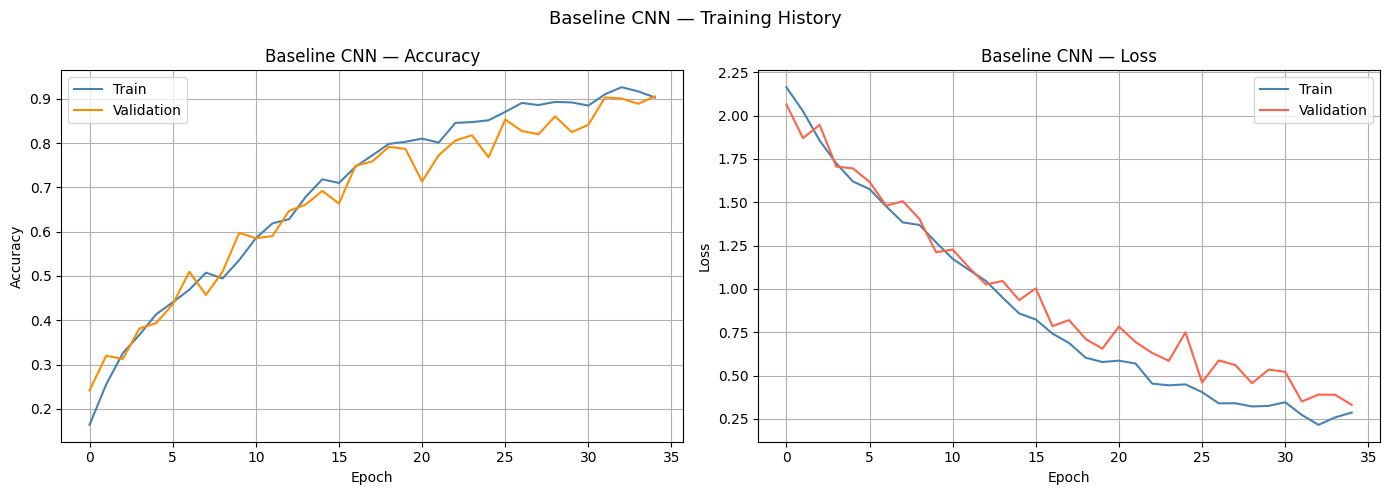

In [ ]:
#Accuracy and Loss Graph
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(baseline_history.history['accuracy'],     label='Train',      color='steelblue')
axes[0].plot(baseline_history.history['val_accuracy'], label='Validation', color='darkorange')
axes[0].set_title('Baseline CNN — Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(baseline_history.history['loss'],     label='Train',      color='steelblue')
axes[1].plot(baseline_history.history['val_loss'], label='Validation', color='tomato')
axes[1].set_title('Baseline CNN — Loss'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(True)
plt.suptitle('Baseline CNN — Training History', fontsize=13)
plt.tight_layout(); plt.show()

### Testing on Test Data

In [ ]:
baseline_loss, baseline_acc = baseline_model.evaluate(test_ds)
# Print the final test performance metrics
print(f'Baseline CNN — Test Accuracy : {baseline_acc:.4f}')
print(f'Baseline CNN — Test Loss     : {baseline_loss:.4f}')

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9036 - loss: 0.4311
Baseline CNN — Test Accuracy : 0.9036
Baseline CNN — Test Loss     : 0.4311


### Classification Report

In [ ]:
y_true_base, y_pred_base = [], []
for images, labels in test_ds:
    preds = baseline_model.predict(images, verbose=0)
    y_pred_base.extend(np.argmax(preds, axis=1))
    y_true_base.extend(labels.numpy())
y_true_base = np.array(y_true_base)
y_pred_base = np.array(y_pred_base)

print('Classification Report — Baseline CNN:')
print(classification_report(y_true_base, y_pred_base, target_names=class_names))

Classification Report — Baseline CNN:
              precision    recall  f1-score   support

      aphids       0.91      0.98      0.95        44
    armyworm       0.97      0.84      0.90        43
      beetle       0.96      0.92      0.94        50
    bollworm       0.89      0.94      0.92        36
 grasshopper       0.85      0.98      0.91        46
       mites       0.90      0.83      0.86        42
    mosquito       0.94      0.98      0.96        50
      sawfly       0.83      0.78      0.81        37
  stem_borer       0.86      0.83      0.85        36

    accuracy                           0.90       384
   macro avg       0.90      0.90      0.90       384
weighted avg       0.91      0.90      0.90       384



### Confusion Matrix

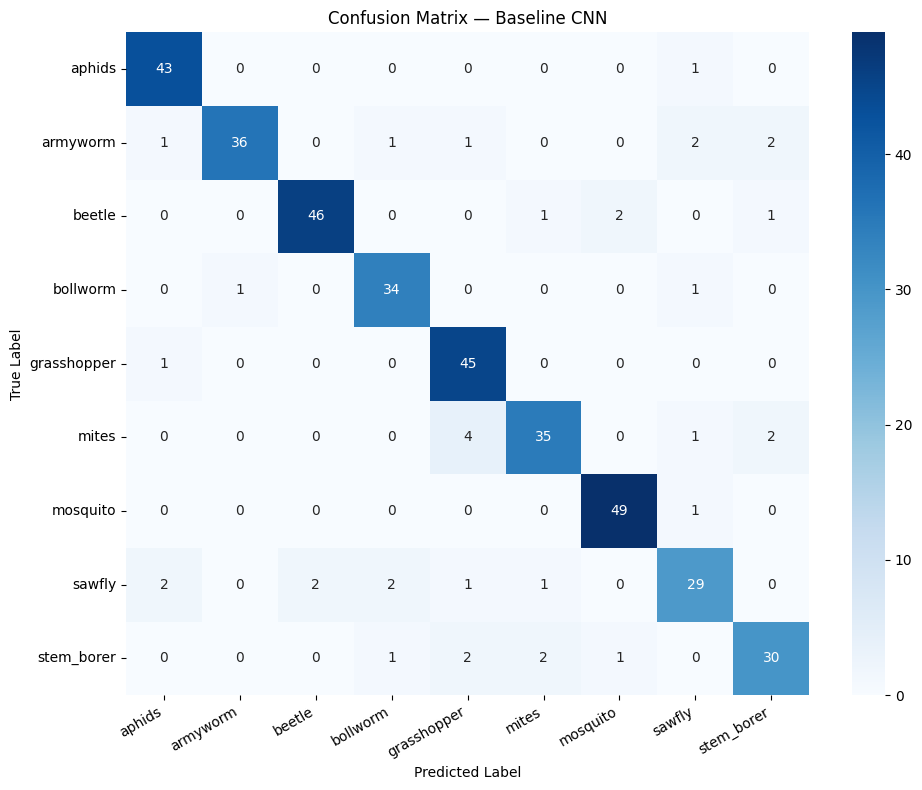

In [ ]:
cm = confusion_matrix(y_true_base, y_pred_base)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Baseline CNN')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

### Inference on Sample Test Images

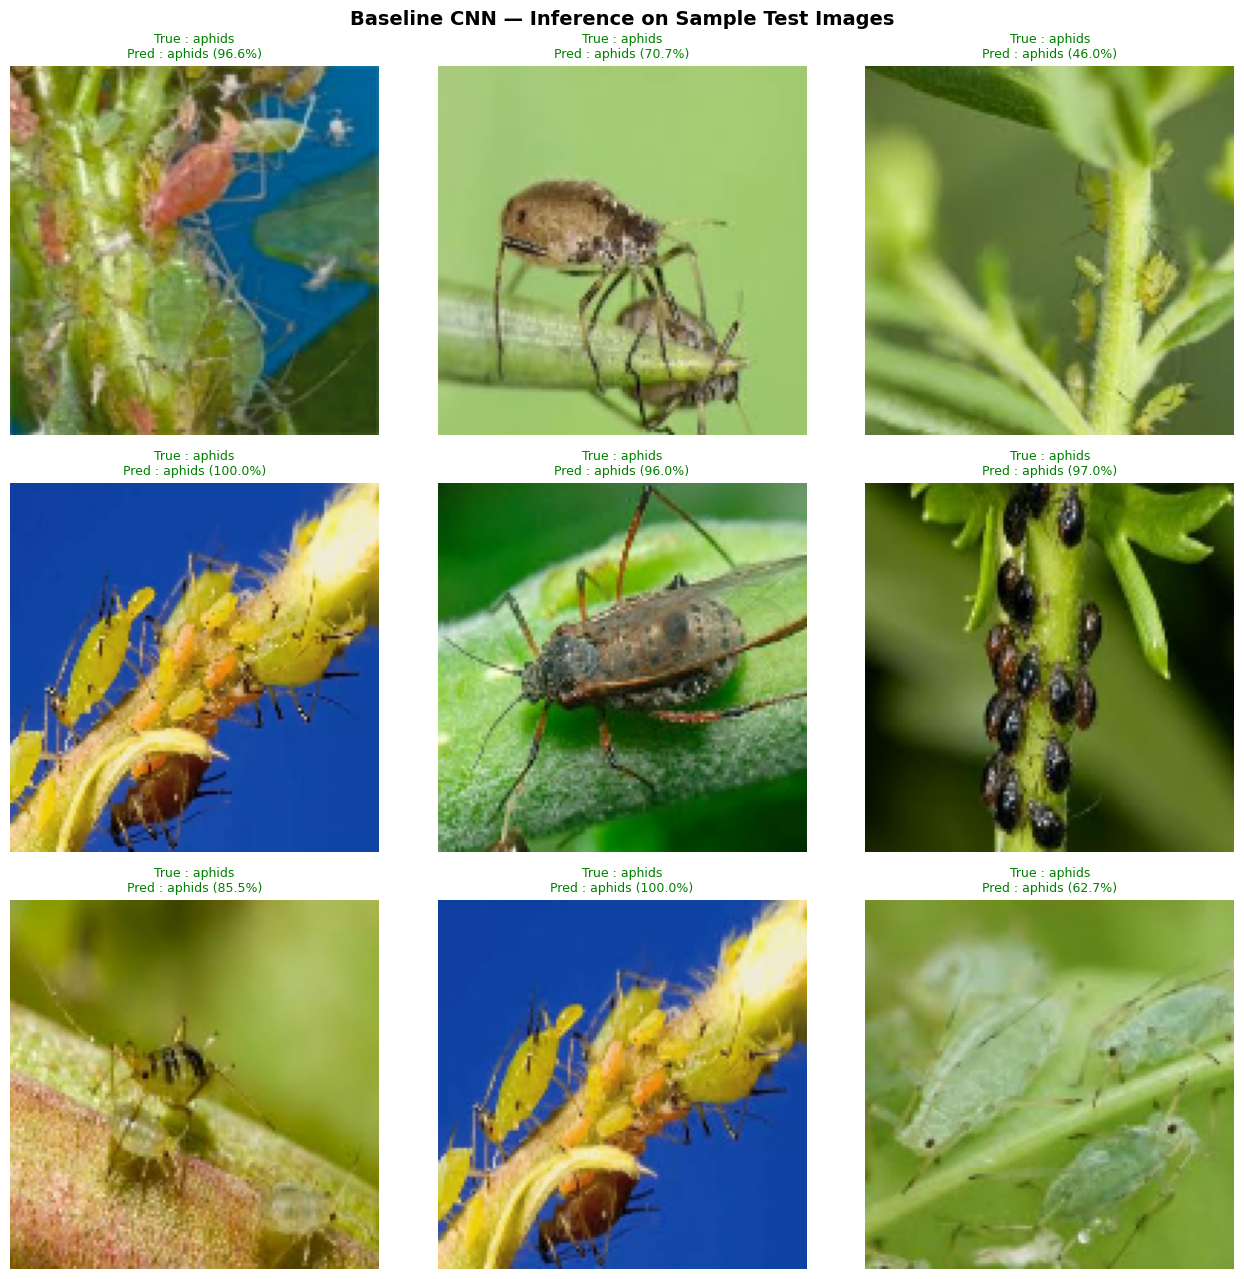

Green = correct   |   Red = wrong


In [ ]:
import random

# Grab one batch from test set
for images, labels in test_ds.take(1):
    sample_images = images.numpy()
    sample_labels = labels.numpy()

# Predict on the whole batch
preds_probs  = baseline_model.predict(images, verbose=0)
pred_classes = np.argmax(preds_probs, axis=1)

# Pick 9 random indices
indices = random.sample(range(len(sample_labels)), min(9, len(sample_labels)))

fig, axes = plt.subplots(3, 3, figsize=(13, 13))
fig.suptitle('Baseline CNN — Inference on Sample Test Images', fontsize=14, fontweight='bold')

for ax, idx in zip(axes.flat, indices):
    ax.imshow(sample_images[idx].astype('uint8'))
    true_label = class_names[sample_labels[idx]]
    pred_label = class_names[pred_classes[idx]]
    confidence = preds_probs[idx][pred_classes[idx]] * 100
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(
        f'True : {true_label}\nPred : {pred_label} ({confidence:.1f}%)',
        fontsize=9, color=color
    )
    ax.axis('off')

plt.tight_layout()
plt.show()
print("Green = correct   |   Red = wrong")

# Deeper Architecture

## Adam Optimizer

### Building Deeper Model with ADAM

In [ ]:
# Build a deeper, more powerful CNN using the Sequential API
# Compared to the baseline, this model has:
# - 6 convolutional blocks (vs 3) with progressively more filters
# - BatchNormalization after every Conv2D for training stability
# - Deeper Dense head (3 layers) with Dropout for regularisation
deeper_model = keras.Sequential([

    # Input layer: RGB images of 128×128 pixels
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # Rescaling: normalise pixel values from [0,255] to [0.0, 1.0]
    layers.Rescaling(1./255),

    # --- CONV BLOCK 1: 32 filters ---
    # Conv2D with activation=None: apply BatchNorm before ReLU (BN → ReLU is best practice)
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),  # Normalises each mini-batch to zero mean and unit variance
    Activation('relu'),    # Apply ReLU after BatchNorm
    MaxPooling2D((2, 2)),  # Downsample: 128×128 → 64×64

    # --- CONV BLOCK 2: 64 filters ---
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D((2, 2)),  # 64×64 → 32×32

    # --- CONV BLOCK 3: 128 filters ---
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D((2, 2)),  # 32×32 → 16×16

    # --- CONV BLOCK 4: 256 filters ---
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D((2, 2)),  # 16×16 → 8×8

    # --- CONV BLOCK 5: 512 filters ---
    Conv2D(512, (3, 3), padding='same', activation=None),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D((2, 2)),  # 8×8 → 4×4

    # --- CONV BLOCK 6: 512 filters (no pooling) ---
    # At 4×4 spatial size, further pooling would reduce features too aggressively
    Conv2D(512, (3, 3), padding='same', activation=None),
    BatchNormalization(), Activation('relu'),
    # No MaxPooling here — preserving spatial information at this small scale

    # Flatten: convert 4×4×512 feature maps into a 8192-element 1D vector
    Flatten(),

    # --- DENSE HEAD ---
    # Dense(512) + BatchNorm + ReLU + Dropout(0.4)
    Dense(512, activation=None), BatchNormalization(), Activation('relu'),
    Dropout(0.4),  # Drop 40% of neurons randomly — strong regularisation

    # Dense(256) + BatchNorm + ReLU + Dropout(0.3)
    Dense(256, activation=None), BatchNormalization(), Activation('relu'),
    Dropout(0.3),  # Drop 30% of neurons

    # Dense(128) + BatchNorm + ReLU + Dropout(0.3)
    Dense(128, activation=None), BatchNormalization(), Activation('relu'),
    Dropout(0.3),

    # Output layer: softmax gives a probability per class
    Dense(num_classes, activation='softmax')

], name='Deeper_CNN')

# Print full architecture summary with parameter counts
deeper_model.summary()



Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 8,298,185 (31.66 MB)

 Trainable params: 8,293,385 (31.64 MB)

 Non-trainable params: 4,800 (18.75 KB)

### Compiling

In [ ]:
deeper_model.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
deeper_checkpoint = ModelCheckpoint(
    'best_deeper_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
deeper_earlystop = EarlyStopping(
    monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1)
print('Deeper model compiled with Adam!')

Deeper model compiled with Adam!


### Training

In [ ]:
deeper_start_adam = time.time()
deeper_history_adam = deeper_model.fit(
    train_ds, epochs=35, validation_data=val_ds,
    callbacks=[deeper_checkpoint, deeper_earlystop]
)
deeper_time_adam = time.time() - deeper_start_adam
print(f'\nDeeper CNN (Adam) training time: {deeper_time_adam/60:.1f} minutes')

Epoch 1/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.1624 - loss: 2.4953
Epoch 1: val_accuracy improved from None to 0.14218, saving model to best_deeper_model.keras

Epoch 1: finished saving model to best_deeper_model.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 30s 312ms/step - accuracy: 0.2114 - loss: 2.2876 - val_accuracy: 0.1422 - val_loss: 2.2322
Epoch 2/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.3011 - loss: 2.0306
Epoch 2: val_accuracy improved from 0.14218 to 0.19194, saving model to best_deeper_model.keras

Epoch 2: finished saving model to best_deeper_model.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 165ms/step - accuracy: 0.3215 - loss: 1.9496 - val_accuracy: 0.1919 - val_loss: 2.3658
Epoch 3/35
52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.3597 - loss: 1.8561
Epoch 3: val_accuracy did not improve from 0.19194
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - accuracy: 0.3766 - loss: 1.7719 - val_accuracy: 0.1161 - val_loss: 2.5329
Epoch 4/35
53/53 ━━━━━━━━━━━━━━━

### Deeper(ADAM) Accuracy and Loss Graph

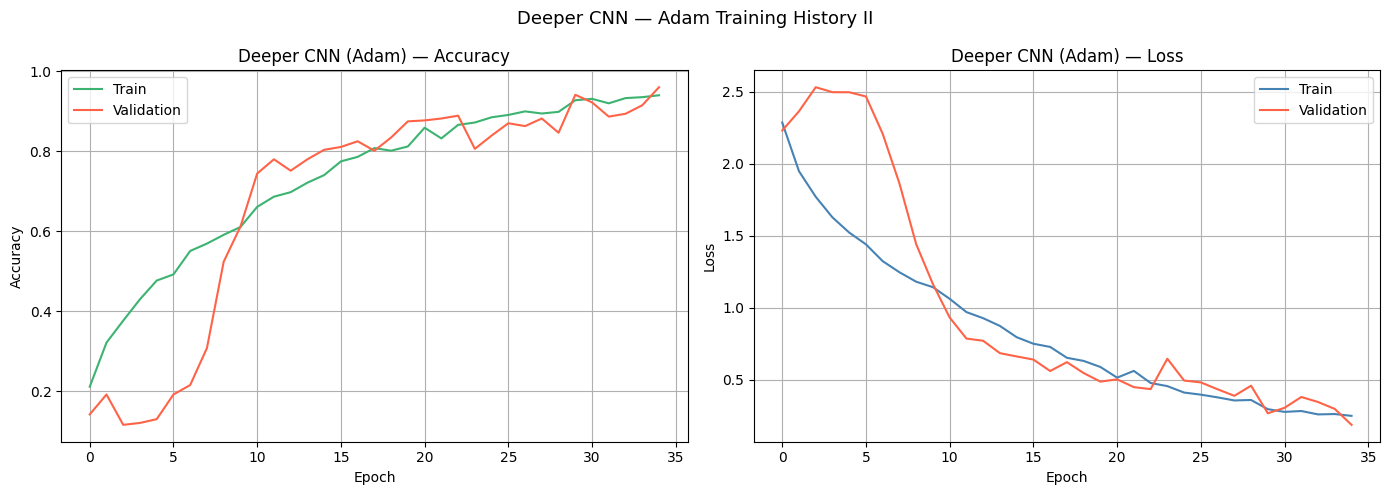

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(deeper_history_adam.history['accuracy'],     label='Train',      color='mediumseagreen')
axes[0].plot(deeper_history_adam.history['val_accuracy'], label='Validation', color='tomato')
axes[0].set_title('Deeper CNN (Adam) — Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(deeper_history_adam.history['loss'],     label='Train',      color='steelblue')
axes[1].plot(deeper_history_adam.history['val_loss'], label='Validation', color='tomato')
axes[1].set_title('Deeper CNN (Adam) — Loss'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(True)
plt.suptitle('Deeper CNN — Adam Training History II', fontsize=13)
plt.tight_layout(); plt.show()

### Testing on Test Images

In [ ]:
deeper_loss_adam, deeper_acc_adam = deeper_model.evaluate(test_ds)
print(f'Deeper CNN (Adam) — Test Accuracy : {deeper_acc_adam:.4f}')
print(f'Deeper CNN (Adam) — Test Loss     : {deeper_loss_adam:.4f}')

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9505 - loss: 0.2346
Deeper CNN (Adam) — Test Accuracy : 0.9505
Deeper CNN (Adam) — Test Loss     : 0.2346


### Classification Report

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Collect true labels and predictions
y_true_deep, y_pred_deep = [], []

for images, labels in test_ds:
    preds = deeper_model.predict(images, verbose=0)
    y_pred_deep.extend(np.argmax(preds, axis=1))
    y_true_deep.extend(labels.numpy())

y_true_deep = np.array(y_true_deep)
y_pred_deep = np.array(y_pred_deep)

print('Classification Report — Deeper CNN (Adam):')
print(classification_report(y_true_deep, y_pred_deep, target_names=class_names))

Classification Report — Deeper CNN (Adam):
              precision    recall  f1-score   support

      aphids       0.94      1.00      0.97        44
    armyworm       0.91      0.95      0.93        43
      beetle       0.98      0.96      0.97        50
    bollworm       1.00      1.00      1.00        36
 grasshopper       0.94      0.98      0.96        46
       mites       0.91      0.93      0.92        42
    mosquito       0.93      1.00      0.96        50
      sawfly       1.00      0.84      0.91        37
  stem_borer       1.00      0.86      0.93        36

    accuracy                           0.95       384
   macro avg       0.96      0.95      0.95       384
weighted avg       0.95      0.95      0.95       384



###Confusion Matrix

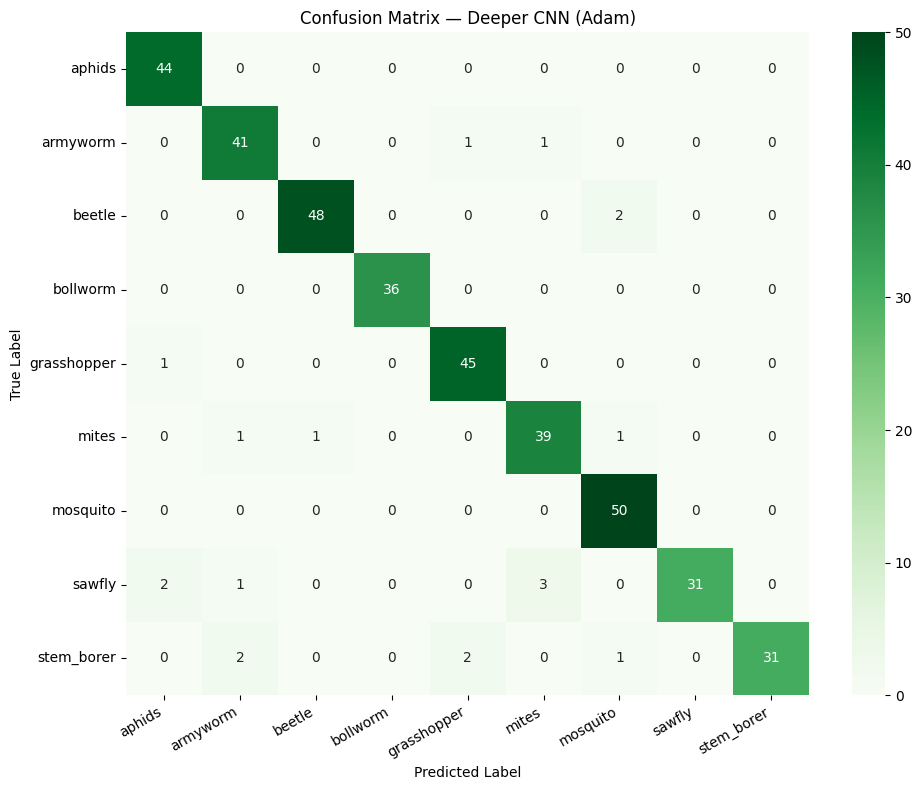

In [ ]:
cm_deep = confusion_matrix(y_true_deep, y_pred_deep)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix — Deeper CNN (Adam)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Deeper Model (SDG)

### Building Deeper Model with SDG

In [ ]:
def build_deeper_model():
    """Returns a fresh deeper CNN with correct Dropout placement."""
    m = keras.Sequential([
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.Rescaling(1./255),  # Normalise — augmentation already in pipeline
        Conv2D(32,  (3,3), padding='same', activation=None), BatchNormalization(), Activation('relu'), MaxPooling2D((2,2)),
        Conv2D(64,  (3,3), padding='same', activation=None), BatchNormalization(), Activation('relu'), MaxPooling2D((2,2)),
        Conv2D(128, (3,3), padding='same', activation=None), BatchNormalization(), Activation('relu'), MaxPooling2D((2,2)),
        Conv2D(256, (3,3), padding='same', activation=None), BatchNormalization(), Activation('relu'), MaxPooling2D((2,2)),
        Conv2D(512, (3,3), padding='same', activation=None), BatchNormalization(), Activation('relu'), MaxPooling2D((2,2)),
        Conv2D(512, (3,3), padding='same', activation=None), BatchNormalization(), Activation('relu'),
        Flatten(),
        Dense(512, activation=None), BatchNormalization(), Activation('relu'), Dropout(0.5),
        Dense(256, activation=None), BatchNormalization(), Activation('relu'), Dropout(0.4),
        Dense(128, activation=None), BatchNormalization(), Activation('relu'), Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return m

# Create the model instance
deeper_model = build_deeper_model()

# Print the summary
deeper_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 8,298,185 (31.66 MB)

 Trainable params: 8,293,385 (31.64 MB)

 Non-trainable params: 4,800 (18.75 KB)

### Compiling

In [ ]:
deeper_model_sgd = build_deeper_model()
deeper_model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='sparse_categorical_crossentropy', metrics=['accuracy']
)
sgd_checkpoint = ModelCheckpoint(
    'best_deeper_model_sgd.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
sgd_earlystop = EarlyStopping(
    monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1)

### Training

In [ ]:
deeper_start_sgd = time.time()
deeper_history_sgd = deeper_model_sgd.fit(
    train_ds, epochs=35, validation_data=val_ds,
    callbacks=[sgd_checkpoint, sgd_earlystop]
)
deeper_time_sgd = time.time() - deeper_start_sgd
print(f'\nDeeper CNN (SGD) training time: {deeper_time_sgd/60:.1f} minutes')

Epoch 1/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.1374 - loss: 2.5564
Epoch 1: val_accuracy improved from None to 0.18483, saving model to best_deeper_model_sgd.keras

Epoch 1: finished saving model to best_deeper_model_sgd.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 300ms/step - accuracy: 0.1652 - loss: 2.3909 - val_accuracy: 0.1848 - val_loss: 5.6852
Epoch 2/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.2270 - loss: 2.1414
Epoch 2: val_accuracy did not improve from 0.18483
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 209ms/step - accuracy: 0.2499 - loss: 2.0716 - val_accuracy: 0.1161 - val_loss: 2.5569
Epoch 3/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.2961 - loss: 1.9254
Epoch 3: val_accuracy did not improve from 0.18483
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - accuracy: 0.3138 - loss: 1.8933 - val_accuracy: 0.1848 - val_loss: 2.3183
Epoch 4/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.3366 - loss: 1.8105
Epoch 4: val_accuracy improved from 0.184

### Deeper(SDG) Accuracy and Loss Graph

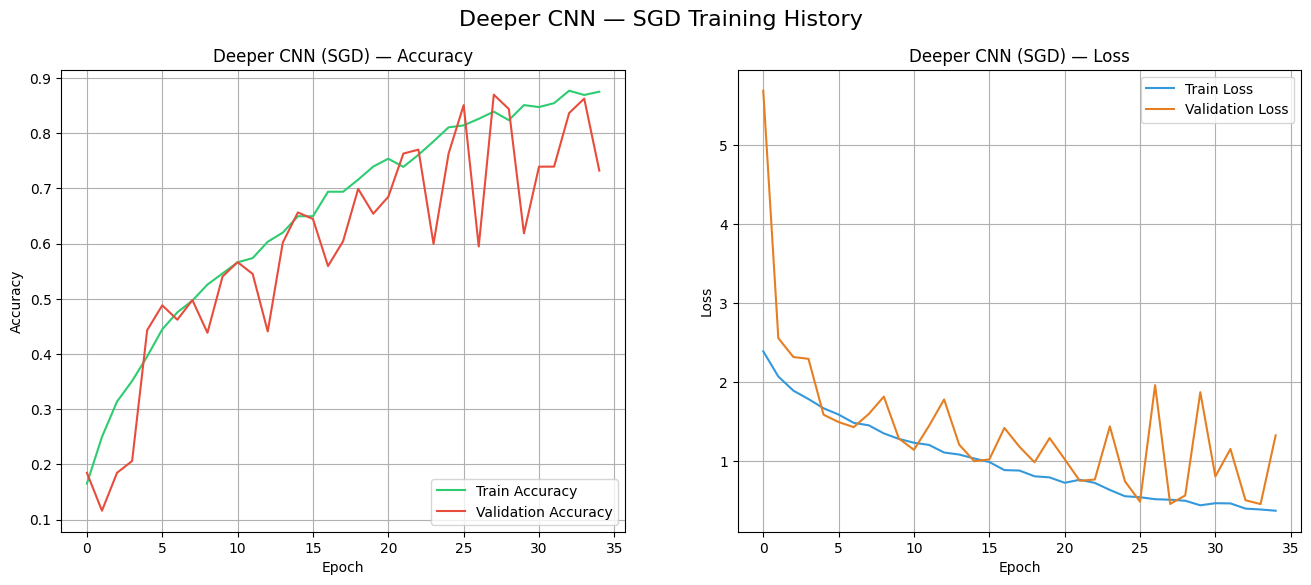

In [ ]:
import matplotlib.pyplot as plt

# Extract history data
acc = deeper_history_sgd.history['accuracy']
val_acc = deeper_history_sgd.history['val_accuracy']
loss = deeper_history_sgd.history['loss']
val_loss = deeper_history_sgd.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(16, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy', color='#2ecc71')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#e74c3c')
plt.title('Deeper CNN (SGD) — Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss', color='#3498db')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='#e67e22')
plt.title('Deeper CNN (SGD) — Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.suptitle('Deeper CNN — SGD Training History', fontsize=16)
plt.show()

### Testing in Test Images

In [ ]:
deeper_loss_sgd, deeper_acc_sgd = deeper_model_sgd.evaluate(test_ds)
print(f'Deeper CNN (SGD) — Test Accuracy : {deeper_acc_sgd:.4f}')
print(f'Deeper CNN (SGD) — Test Loss     : {deeper_loss_sgd:.4f}')

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8828 - loss: 0.5758
Deeper CNN (SGD) — Test Accuracy : 0.8828
Deeper CNN (SGD) — Test Loss     : 0.5758


### Classification Report

In [ ]:
y_true_sgd, y_pred_sgd = [], []
for images, labels in test_ds:
    preds = deeper_model_sgd.predict(images, verbose=0)
    y_pred_sgd.extend(np.argmax(preds, axis=1))
    y_true_sgd.extend(labels.numpy())

y_true_sgd = np.array(y_true_sgd)
y_pred_sgd = np.array(y_pred_sgd)

print('\nClassification Report — Deeper CNN (SGD):')
print(classification_report(y_true_sgd, y_pred_sgd, target_names=class_names))


Classification Report — Deeper CNN (SGD):
              precision    recall  f1-score   support

      aphids       0.86      1.00      0.93        44
    armyworm       0.94      0.77      0.85        43
      beetle       0.96      0.96      0.96        50
    bollworm       0.80      0.92      0.86        36
 grasshopper       0.84      0.89      0.86        46
       mites       0.79      0.90      0.84        42
    mosquito       0.92      0.98      0.95        50
      sawfly       0.87      0.70      0.78        37
  stem_borer       1.00      0.75      0.86        36

    accuracy                           0.88       384
   macro avg       0.89      0.87      0.88       384
weighted avg       0.89      0.88      0.88       384



### Confusion Matrix

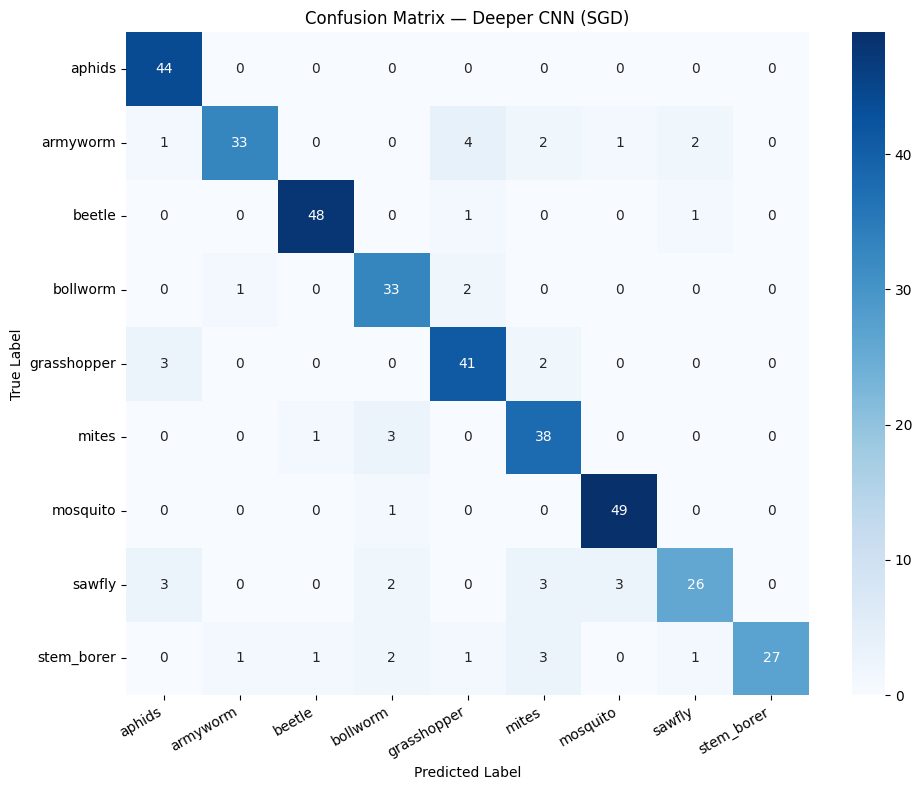

In [ ]:
# Plotting Confusion Matrix
cm_sgd = confusion_matrix(y_true_sgd, y_pred_sgd)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_sgd, annot=True, fmt='d', cmap='Blues', # Changed color to Blues for SGD
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Deeper CNN (SGD)')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

## Comparing Adam and SDG accuracy and loss

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8828 - loss: 0.5758


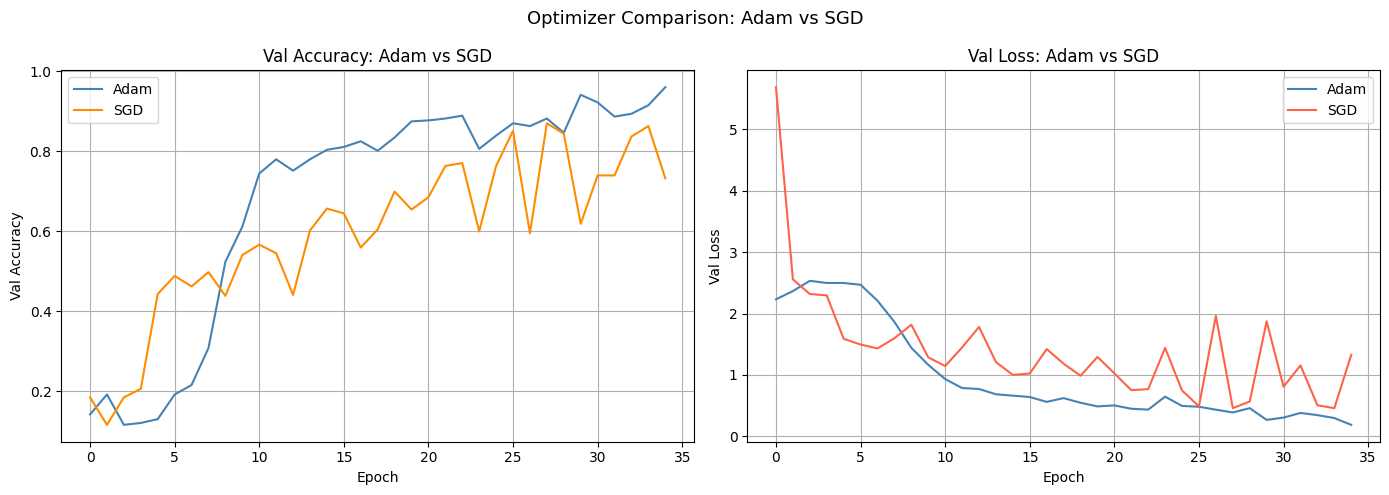

In [ ]:
deeper_loss_sgd, deeper_acc_sgd = deeper_model_sgd.evaluate(test_ds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(deeper_history_adam.history['val_accuracy'], label='Adam', color='steelblue')
axes[0].plot(deeper_history_sgd.history['val_accuracy'],  label='SGD',  color='darkorange')
axes[0].set_title('Val Accuracy: Adam vs SGD'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Val Accuracy'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(deeper_history_adam.history['val_loss'], label='Adam', color='steelblue')
axes[1].plot(deeper_history_sgd.history['val_loss'],  label='SGD',  color='tomato')
axes[1].set_title('Val Loss: Adam vs SGD'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Loss'); axes[1].legend(); axes[1].grid(True)
plt.suptitle('Optimizer Comparison: Adam vs SGD', fontsize=13)
plt.tight_layout()


## Ablation Study


### Building Model (No Dropout)

In [ ]:
ablation_model = keras.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Rescaling(1./255),  # Normalise — augmentation already in pipeline
    Conv2D(32,  (3,3), padding='same', activation=None), BatchNormalization(), Activation('relu'), MaxPooling2D((2,2)),
    Conv2D(64,  (3,3), padding='same', activation=None), BatchNormalization(), Activation('relu'), MaxPooling2D((2,2)),
    Conv2D(128, (3,3), padding='same', activation=None), BatchNormalization(), Activation('relu'), MaxPooling2D((2,2)),
    Conv2D(256, (3,3), padding='same', activation=None), BatchNormalization(), Activation('relu'), MaxPooling2D((2,2)),
    Conv2D(512, (3,3), padding='same', activation=None), BatchNormalization(), Activation('relu'), MaxPooling2D((2,2)),
    Conv2D(512, (3,3), padding='same', activation=None), BatchNormalization(), Activation('relu'),
    Flatten(),
    # Dropout REMOVED — this is the ablation component
    Dense(512, activation=None), BatchNormalization(), Activation('relu'),
    Dense(256, activation=None), BatchNormalization(), Activation('relu'),
    Dense(128, activation=None), BatchNormalization(), Activation('relu'),
    Dense(num_classes, activation='softmax')
], name='Deeper_CNN_No_Dropout')

ablation_model.summary()

Model: "Deeper_CNN_No_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_6 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_45 (Activation)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_46 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_47 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_48 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_49 (Activation)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 8,298,185 (31.66 MB)

 Trainable params: 8,293,385 (31.64 MB)

 Non-trainable params: 4,800 (18.75 KB)

### Compiling

In [ ]:

ablation_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ablation_earlystop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)


### Training

In [ ]:
ablation_start = time.time()
ablation_history = ablation_model.fit(
    train_ds,
    epochs=35,
    validation_data=val_ds,
    callbacks=[ablation_earlystop]
)
ablation_time = time.time() - ablation_start

Epoch 1/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 350ms/step - accuracy: 0.3422 - loss: 1.8554 - val_accuracy: 0.1161 - val_loss: 2.8360
Epoch 2/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 219ms/step - accuracy: 0.4482 - loss: 1.5677 - val_accuracy: 0.1825 - val_loss: 3.3060
Epoch 3/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 214ms/step - accuracy: 0.5299 - loss: 1.3228 - val_accuracy: 0.1066 - val_loss: 3.7782
Epoch 4/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 201ms/step - accuracy: 0.5850 - loss: 1.1799 - val_accuracy: 0.1564 - val_loss: 4.0763
Epoch 5/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 190ms/step - accuracy: 0.6542 - loss: 0.9733 - val_accuracy: 0.1754 - val_loss: 4.1188
Epoch 6/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 12s 216ms/step - accuracy: 0.6815 - loss: 0.9318 - val_accuracy: 0.3294 - val_loss: 2.2161
Epoch 7/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 189ms/step - accuracy: 0.7365 - loss: 0.7974 - val_accuracy: 0.3697 - val_loss: 2.0974
Epoch 8/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - accuracy: 0.7738 - loss: 0.6545 - val_accur

### Model(No Dropout) Accuracy and Loss Graph

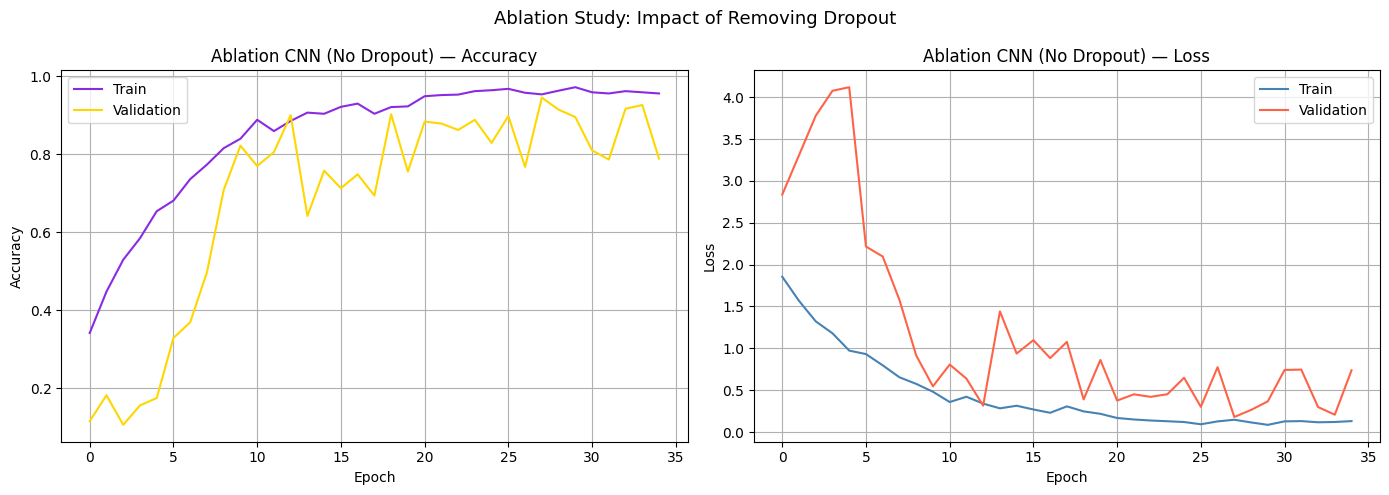

In [ ]:
# --- Plotting Ablation (No Dropout) Training History ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
axes[0].plot(ablation_history.history['accuracy'],     label='Train',      color='blueviolet')
axes[0].plot(ablation_history.history['val_accuracy'], label='Validation', color='gold')
axes[0].set_title('Ablation CNN (No Dropout) — Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

# Loss Plot
axes[1].plot(ablation_history.history['loss'],     label='Train',      color='steelblue')
axes[1].plot(ablation_history.history['val_loss'], label='Validation', color='tomato')
axes[1].set_title('Ablation CNN (No Dropout) — Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('Ablation Study: Impact of Removing Dropout', fontsize=13)
plt.tight_layout()
plt.show()

### Testing in Test Images

In [ ]:
ablation_loss, ablation_acc = ablation_model.evaluate(test_ds)
change = (deeper_acc_adam - ablation_acc) * 100
print(f'\nAblation (No Dropout)      — Test Accuracy: {ablation_acc:.4f}')
print(f'Ablation (No Dropout)      — Test Loss:     {ablation_loss:.4f}')

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.9167 - loss: 0.4166

Ablation (No Dropout)      — Test Accuracy: 0.9167
Ablation (No Dropout)      — Test Loss:     0.4166


### Classification Report

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Collect true labels and predictions for the ablation model
y_true_ablation, y_pred_ablation = [], []

for images, labels in test_ds:
    preds = ablation_model.predict(images, verbose=0)
    y_pred_ablation.extend(np.argmax(preds, axis=1))
    y_true_ablation.extend(labels.numpy())

y_true_ablation = np.array(y_true_ablation)
y_pred_ablation = np.array(y_pred_ablation)

# Print Classification Report for the Ablation Model
print('Classification Report — Ablation Model (No Dropout):')
print(classification_report(y_true_ablation, y_pred_ablation, target_names=class_names))

Classification Report — Ablation Model (No Dropout):
              precision    recall  f1-score   support

      aphids       0.88      1.00      0.94        44
    armyworm       1.00      0.84      0.91        43
      beetle       0.96      0.96      0.96        50
    bollworm       0.86      1.00      0.92        36
 grasshopper       0.75      0.89      0.81        46
       mites       0.97      0.93      0.95        42
    mosquito       0.98      1.00      0.99        50
      sawfly       0.94      0.81      0.87        37
  stem_borer       1.00      0.78      0.88        36

    accuracy                           0.92       384
   macro avg       0.93      0.91      0.91       384
weighted avg       0.93      0.92      0.92       384



### Confusion Matrix

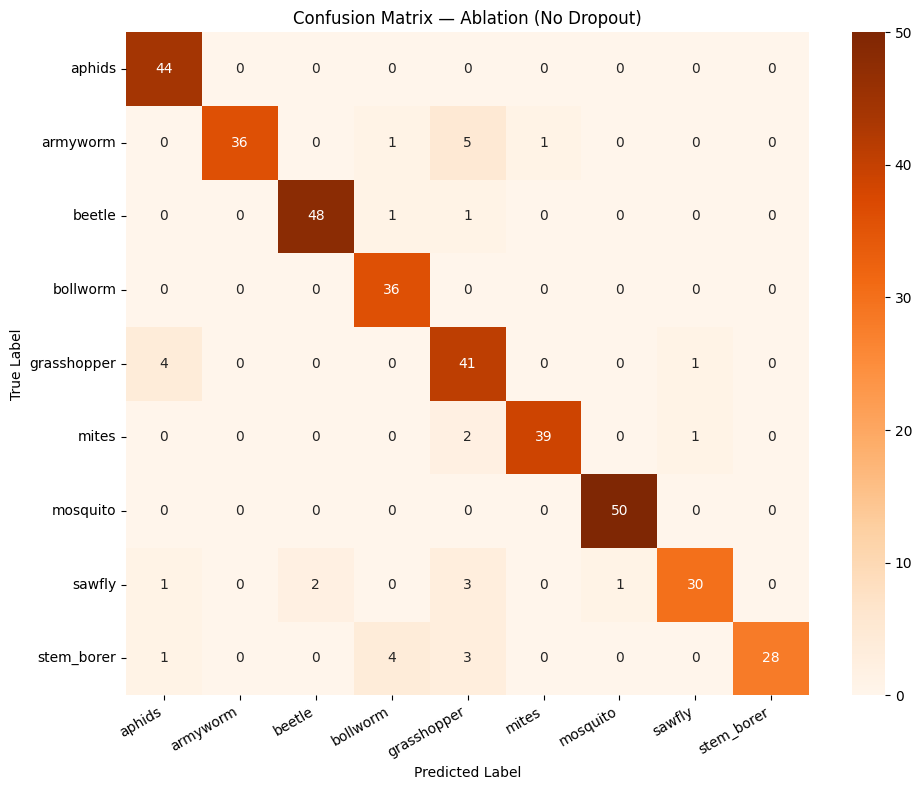

In [ ]:
# Plot Confusion Matrix for the Ablation Model
cm_ablation = confusion_matrix(y_true_ablation, y_pred_ablation)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_ablation, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix — Ablation (No Dropout)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Comparing all the models

Model                                 Test Accuracy      Train Time
--------------------------------------------------------------------
Baseline CNN                                  90.4%        5.5 min
Deeper CNN (Adam)                             95.1%        5.5 min
Deeper CNN (SGD)                              88.3%        5.5 min
No Dropout (Ablation)                         91.7%        6.3 min


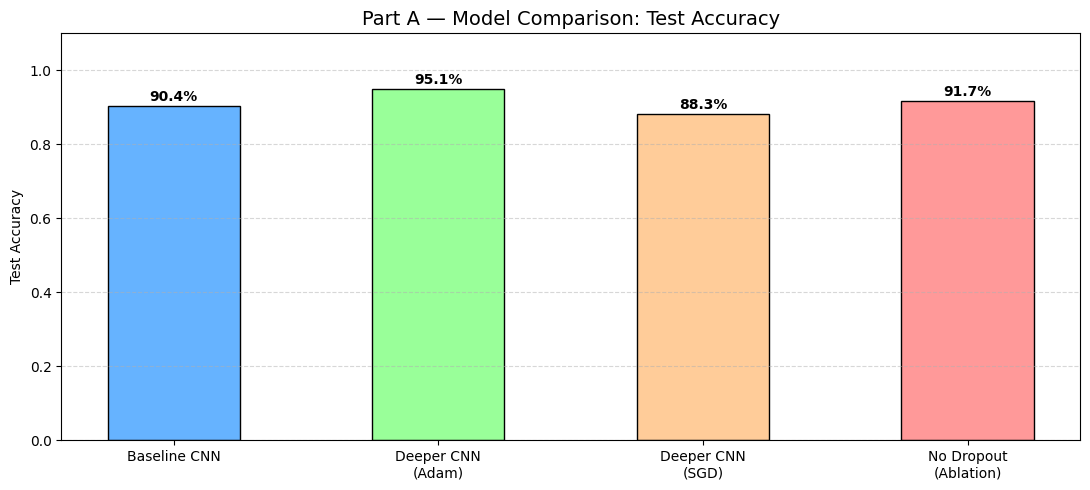

In [ ]:
model_labels = ['Baseline CNN', 'Deeper CNN\n(Adam)', 'Deeper CNN\n(SGD)', 'No Dropout\n(Ablation)']
accuracies   = [baseline_acc, deeper_acc_adam, deeper_acc_sgd, ablation_acc]
times_min    = [baseline_time/60, deeper_time_adam/60, deeper_time_sgd/60, ablation_time/60]

print(f"{'Model':<35} {'Test Accuracy':>15} {'Train Time':>15}")
print('-' * 68)
for name, acc, t in zip(['Baseline CNN','Deeper CNN (Adam)','Deeper CNN (SGD)','No Dropout (Ablation)'],
                         accuracies, times_min):
    t_str = f'{t:.1f} min' if t is not None else 'N/A'
    print(f'{name:<35} {acc*100:>14.1f}%  {t_str:>13}')

colors = ['#66b3ff', '#99ff99', '#ffcc99', '#ff9999']
plt.figure(figsize=(11, 5))
bars = plt.bar(model_labels, accuracies, color=colors, edgecolor='black', width=0.5)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.005,
             f'{h*100:.1f}%', ha='center', va='bottom', fontweight='bold')
plt.title('Part A — Model Comparison: Test Accuracy', fontsize=14)
plt.ylabel('Test Accuracy'); plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

In [ ]:
print(f'Deeper CNN (With Dropout)  — Test Accuracy: {deeper_acc_adam:.4f}')
print(f'Dropout effect: {change:+.2f}% ({"improvement" if change > 0 else "regression"} when Dropout used)')

# Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)

## VGG

### VGG16 TRANSFER LEARNING

In [ ]:
# ============================================================
# PART B — VGG16 TRANSFER LEARNING
# Section 2.6: Fine-Tuning a Pre-Trained Model
# ============================================================
# Spec says:
#   "Select an appropriate pre-trained CNN model (e.g. VGG, ResNet, Inception)"
#   "Load the pre-trained model using keras"
#   "ImageNet models expect a specific input image size (224x224 for VGG)"
#   "Resize dataset images to match the required dimensions"
# ============================================================

VGG_SIZE = (224, 224)

# Reload train and validation from train_dir at 224x224
# Same seed=42 and 80/20 split as Part A — consistent evaluation
train_ds_vgg, val_ds_vgg = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='both',
    seed=42,
    image_size=VGG_SIZE,
    batch_size=BATCH_SIZE,
)

# Test set — shuffle=False for accurate ordered predictions
test_ds_vgg = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=VGG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f'Train batches : {len(train_ds_vgg)}')
print(f'Val batches   : {len(val_ds_vgg)}')
print(f'Test batches  : {len(test_ds_vgg)}')

Found 2111 files belonging to 9 classes.
Using 1689 files for training.
Using 422 files for validation.
Found 384 files belonging to 9 classes.
Train batches : 53
Val batches   : 14
Test batches  : 12


### VGG16 Preprocessing

In [ ]:
# ============================================================
# VGG16 Preprocessing — CRITICAL
# Spec says: "Resize dataset images to match required dimensions
#             using appropriate Data Generator in Keras"
#
# VGG16 was trained with preprocess_input (channel mean subtraction)
# NOT with 1/255 rescaling — using wrong preprocessing is a common
# mistake that significantly hurts transfer learning performance
# ============================================================
from tensorflow.keras.applications.vgg16 import preprocess_input

train_ds_vgg = train_ds_vgg.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

val_ds_vgg = val_ds_vgg.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

test_ds_vgg = test_ds_vgg.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

print('Datasets preprocessed with VGG16 preprocess_input')
print('(ImageNet channel mean subtraction applied — NOT 1/255 rescaling)')

Datasets preprocessed with VGG16 preprocess_input
(ImageNet channel mean subtraction applied — NOT 1/255 rescaling)


### Load VGG16 Pre-Trained Base

In [ ]:
# ============================================================
# Load VGG16 Pre-Trained Base
# Spec says:
#   "Load the pre-trained model using keras"
#   "Remove the original fully connected layers"
#   "include_top=False removes the 1000-class head"
#   "Freeze certain layers — feature extraction approach"
# ============================================================
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# include_top=False: removes VGG16's 1000-class classification head
# weights='imagenet': loads weights learned on 1.2M ImageNet images
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze ALL VGG16 layers — Feature Extraction strategy
# Spec says: "Freeze the convolutional base to retain previously
#             learned feature representations"
# Frozen layers still FORWARD PASS but their weights do NOT update
for layer in base_model.layers:
    layer.trainable = False

trainable   = sum(1 for l in base_model.layers if l.trainable)
frozen      = sum(1 for l in base_model.layers if not l.trainable)
print(f'VGG16 base loaded from ImageNet weights')
print(f'Total VGG16 layers : {len(base_model.layers)}')
print(f'Frozen layers      : {frozen}')
print(f'Trainable layers   : {trainable}')
print(f'VGG16 output shape : {base_model.output_shape}')
print('\nFrozen = weights preserved from ImageNet training')
print('Only the new classification head will be trained')

VGG16 base loaded from ImageNet weights
Total VGG16 layers : 19
Frozen layers      : 19
Trainable layers   : 0
VGG16 output shape : (None, 7, 7, 512)

Frozen = weights preserved from ImageNet training
Only the new classification head will be trained


### Build Classification Head

In [ ]:
# ============================================================
# Build Classification Head
# Spec says:
#   "Add new dense layers tailored to your dataset's number of classes"
#   "ImageNet trained models have 1000-class softmax output"
#   "Modify the final classification layer to match number of classes"
# ============================================================

# Connect new head to VGG16 base output
x = base_model.output                    # shape: (None, 7, 7, 512)

# GlobalAveragePooling2D: (7,7,512) → (512,)
# Better than Flatten for transfer learning — reduces overfitting risk
x = GlobalAveragePooling2D()(x)

# Dense layer 1
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

# Dense layer 2
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

# Output layer — num_classes neurons (NOT 1000 like original VGG16)
# Spec says: "Modify final layer to match number of classes in your dataset"
output = Dense(num_classes, activation='softmax')(x)

# Functional API — combines frozen base + trainable head
transfer_model = Model(inputs=base_model.input, outputs=output)

# Show full summary
print('=== VGG16 Transfer Learning Model Summary ===')
transfer_model.summary()

# Count parameters clearly
total_params     = transfer_model.count_params()
trainable_params = sum(tf.size(w).numpy() for w in transfer_model.trainable_weights)
frozen_params    = total_params - trainable_params
print(f'\nTotal parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}  ← only the new head')
print(f'Frozen parameters    : {frozen_params:,}   ← VGG16 base')

=== VGG16 Transfer Learning Model Summary ===


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,110,985 (57.64 MB)

 Trainable params: 396,297 (1.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


Total parameters     : 15,110,985
Trainable parameters : 396,297  ← only the new head
Frozen parameters    : 14,714,688   ← VGG16 base


###Compiling

In [ ]:
# ============================================================
# Compile Transfer Model
# Spec says: "Train only the newly added layers for classification"
# Small LR = 1e-4 for transfer learning (standard practice)
# Large LR would cause unstable gradients through the deep frozen network
# ============================================================
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

tl_checkpoint = ModelCheckpoint(
    'best_transfer_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
tl_earlystop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print('Transfer model compiled')

Transfer model compiled


### Training

In [ ]:
# ============================================================
# Train VGG16 — Feature Extraction Phase
# ============================================================
print('Training VGG16 Transfer Model — Feature Extraction Phase')

tl_start   = time.time()
tl_history = transfer_model.fit(
    train_ds_vgg,
    epochs=30,
    validation_data=val_ds_vgg,
    callbacks=[tl_checkpoint, tl_earlystop]
)
tl_time = time.time() - tl_start

print(f'\nTraining complete')
print(f'Total training time : {tl_time/60:.1f} minutes')
print(f'Epochs run          : {len(tl_history.history["accuracy"])}')

Training VGG16 Transfer Model — Feature Extraction Phase
Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.1551 - loss: 6.8866
Epoch 1: val_accuracy improved from None to 0.46209, saving model to best_transfer_model.keras

Epoch 1: finished saving model to best_transfer_model.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 40s 676ms/step - accuracy: 0.1883 - loss: 5.5912 - val_accuracy: 0.4621 - val_loss: 1.9598
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.2784 - loss: 3.6620
Epoch 2: val_accuracy improved from 0.46209 to 0.63033, saving model to best_transfer_model.keras

Epoch 2: finished saving model to best_transfer_model.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 268ms/step - accuracy: 0.3102 - loss: 3.2594 - val_accuracy: 0.6303 - val_loss: 1.1280
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.3878 - loss: 2.5479
Epoch 3: val_accuracy improved from 0.63033 to 0.70379, saving model to best_transfer_model.keras

Epoch 3: finished saving model to b

### VGG16 Training and Loss Graph

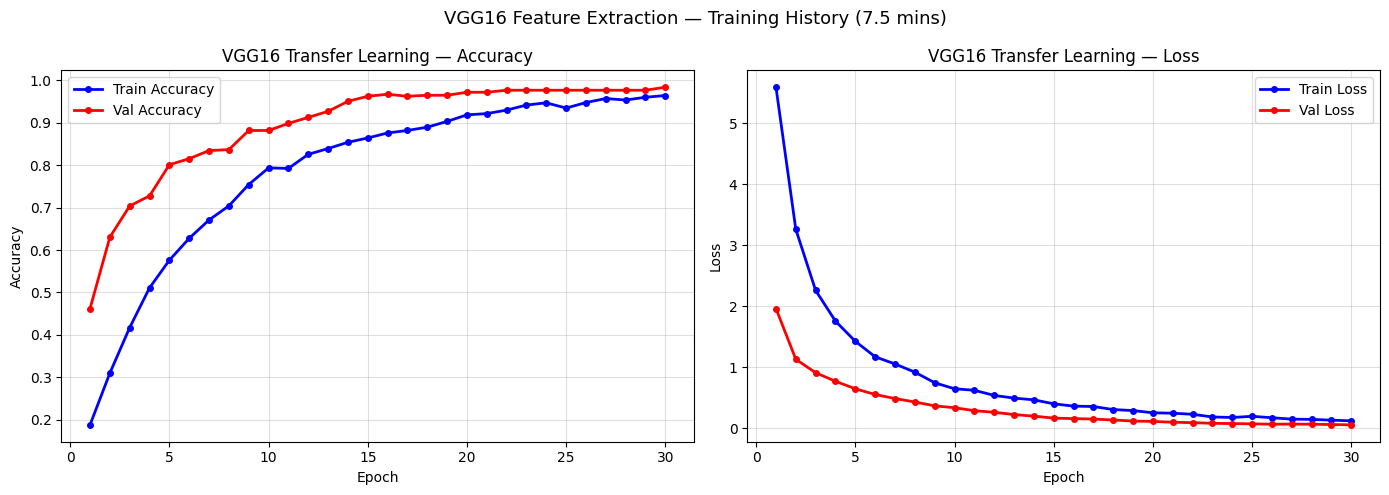

In [ ]:
# ============================================================
# Training Curves — VGG16 Feature Extraction
# Spec says: "Plot training vs validation loss and accuracy"
# ============================================================
epochs_ran = range(1, len(tl_history.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(epochs_ran, tl_history.history['accuracy'],
             'b-o', markersize=4, label='Train Accuracy', lw=2)
axes[0].plot(epochs_ran, tl_history.history['val_accuracy'],
             'r-o', markersize=4, label='Val Accuracy', lw=2)
axes[0].set_title('VGG16 Transfer Learning — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.4)

# Loss
axes[1].plot(epochs_ran, tl_history.history['loss'],
             'b-o', markersize=4, label='Train Loss', lw=2)
axes[1].plot(epochs_ran, tl_history.history['val_loss'],
             'r-o', markersize=4, label='Val Loss', lw=2)
axes[1].set_title('VGG16 Transfer Learning — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.suptitle(
    f'VGG16 Feature Extraction — Training History ({tl_time/60:.1f} mins)',
    fontsize=13
)
plt.tight_layout()
plt.show()

### Training on Test Images

In [ ]:
# ============================================================
# Evaluate VGG16 on Test Set
# Spec says: "Evaluate the fine-tuned model using the same
#             performance metrics as in Part A"
#             i.e. accuracy, confusion matrix, classification report
# ============================================================

vgg_loss, vgg_acc = transfer_model.evaluate(test_ds_vgg, verbose=1)
print(f'\nVGG16 Transfer Learning — Test Accuracy : {vgg_acc:.4f}')
print(f'VGG16 Transfer Learning — Test Loss     : {vgg_loss:.4f}')

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 205ms/step - accuracy: 0.9688 - loss: 0.1255

VGG16 Transfer Learning — Test Accuracy : 0.9688
VGG16 Transfer Learning — Test Loss     : 0.1255


### Classification Report

In [ ]:
# ============================================================
# Classification Report + Confusion Matrix
# Same metrics used in Part A baseline — consistent comparison
# ============================================================

y_true_vgg, y_pred_vgg = [], []
for images, labels in test_ds_vgg:
    preds = transfer_model.predict(images, verbose=0)
    y_pred_vgg.extend(np.argmax(preds, axis=1))
    y_true_vgg.extend(labels.numpy())

y_true_vgg = np.array(y_true_vgg)
y_pred_vgg = np.array(y_pred_vgg)

print('Classification Report — VGG16 Transfer Learning:')
print('=' * 60)
print(classification_report(y_true_vgg, y_pred_vgg, target_names=class_names))

Classification Report — VGG16 Transfer Learning:
              precision    recall  f1-score   support

      aphids       0.90      1.00      0.95        44
    armyworm       0.98      0.93      0.95        43
      beetle       1.00      0.98      0.99        50
    bollworm       0.92      1.00      0.96        36
 grasshopper       1.00      1.00      1.00        46
       mites       0.98      1.00      0.99        42
    mosquito       1.00      1.00      1.00        50
      sawfly       0.97      0.86      0.91        37
  stem_borer       0.97      0.92      0.94        36

    accuracy                           0.97       384
   macro avg       0.97      0.97      0.97       384
weighted avg       0.97      0.97      0.97       384



### Confusion Matrix

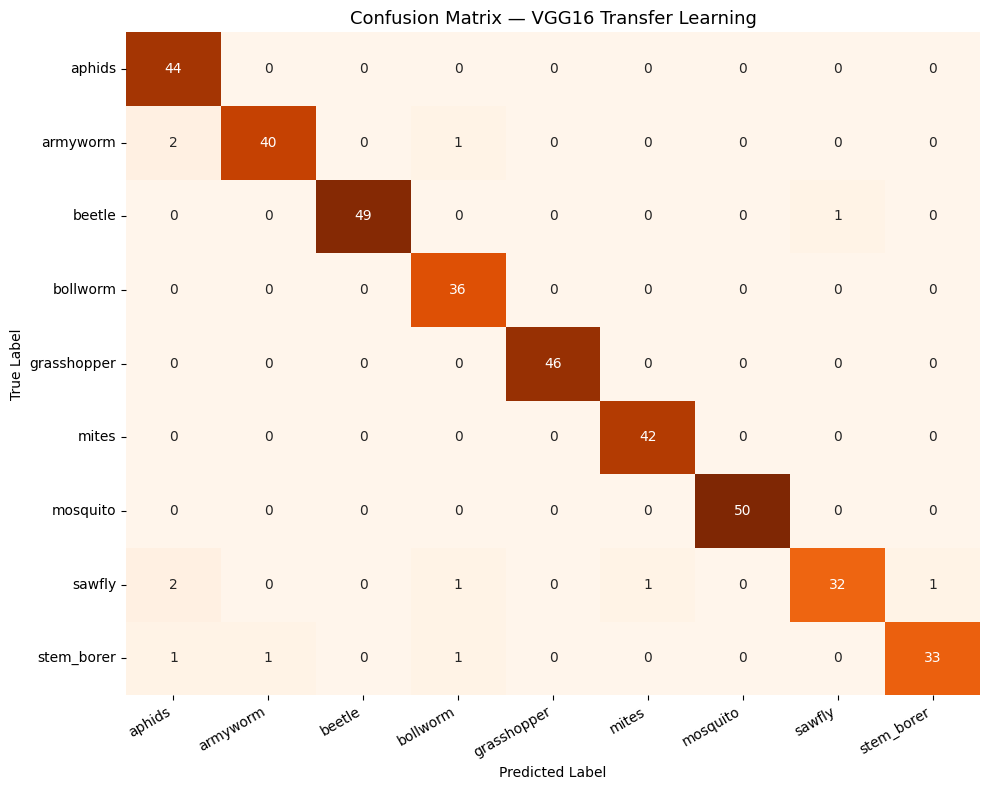

In [ ]:
# Confusion Matrix
cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_vgg, annot=True, fmt='d', cmap='Oranges',
    xticklabels=class_names, yticklabels=class_names, cbar=False
)
plt.title('Confusion Matrix — VGG16 Transfer Learning', fontsize=13)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Inference on Sample Test Images

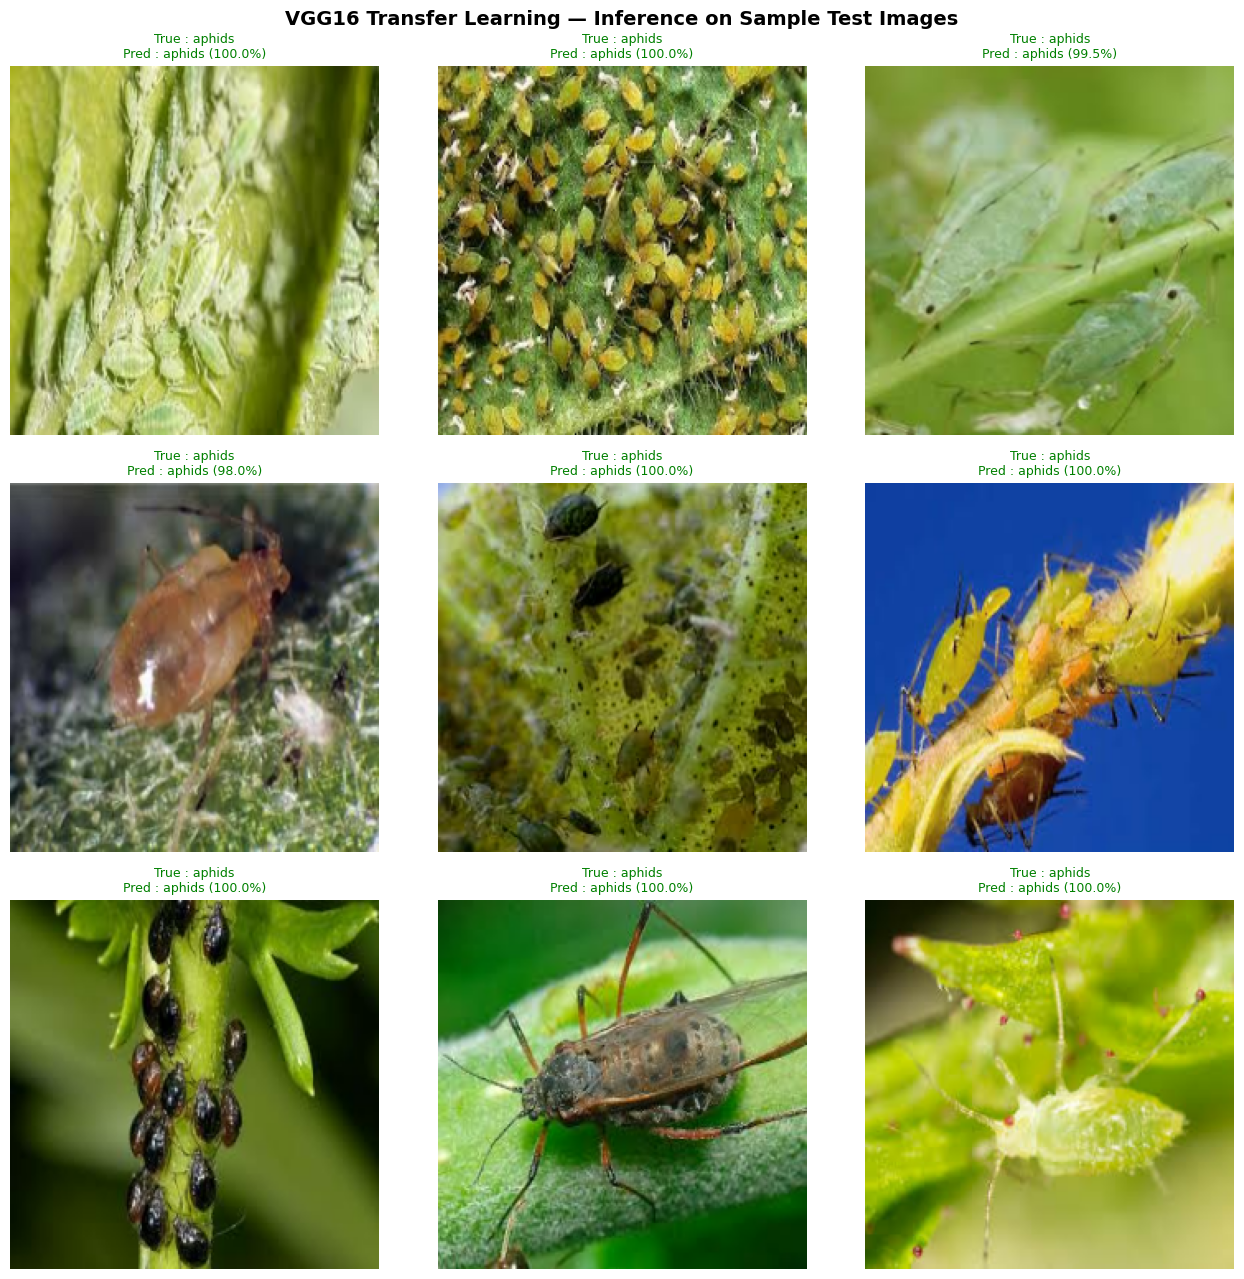

Green title = correct prediction   |   Red title = wrong prediction


In [ ]:
# ============================================================
# Inference on Sample Test Images
# Spec says: "Make predictions on test data and compare results
#             with baseline and deeper models from Part A"
# ============================================================

# Grab one batch
for images_vgg, labels_vgg in test_ds_vgg.take(1):
    sample_images_vgg = images_vgg.numpy()
    sample_labels_vgg = labels_vgg.numpy()

# Predict on the batch
preds_vgg_probs  = transfer_model.predict(images_vgg, verbose=0)
pred_classes_vgg = np.argmax(preds_vgg_probs, axis=1)

# VGG16 preprocess_input subtracts ImageNet channel means
# We reverse it here just for display — does NOT affect predictions
def deprocess_vgg(img):
    img = img.copy().astype('float32')
    img[..., 0] += 103.939   # Blue channel mean
    img[..., 1] += 116.779   # Green channel mean
    img[..., 2] += 123.68    # Red channel mean
    img = img[..., ::-1]     # BGR → RGB
    return np.clip(img, 0, 255).astype('uint8')

# Pick 9 random indices
indices_vgg = random.sample(range(len(sample_labels_vgg)), min(9, len(sample_labels_vgg)))

fig, axes = plt.subplots(3, 3, figsize=(13, 13))
fig.suptitle(
    'VGG16 Transfer Learning — Inference on Sample Test Images',
    fontsize=14, fontweight='bold'
)

for ax, idx in zip(axes.flat, indices_vgg):
    ax.imshow(deprocess_vgg(sample_images_vgg[idx]))
    true_label = class_names[sample_labels_vgg[idx]]
    pred_label = class_names[pred_classes_vgg[idx]]
    confidence = preds_vgg_probs[idx][pred_classes_vgg[idx]] * 100
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(
        f'True : {true_label}\nPred : {pred_label} ({confidence:.1f}%)',
        fontsize=9, color=color
    )
    ax.axis('off')

plt.tight_layout()
plt.show()
print('Green title = correct prediction   |   Red title = wrong prediction')

## FINAL MODEL COMPARISON

In [ ]:
# ============================================================
# Compare VGG16 vs Part A Models
# Spec says: "Discuss whether transfer learning outperforms
#             training from scratch for your dataset"
# ============================================================

print('\nTransfer Learning vs From Scratch — Comparison')
print(f'Baseline CNN           : {baseline_acc*100:.2f}%')
print(f'Deeper CNN (Adam)      : {deeper_acc_adam*100:.2f}%')
print(f'Deeper CNN (SGD)       : {deeper_acc_sgd*100:.2f}%')
print(f'No Dropout (Ablation)  : {ablation_acc*100:.2f}%')
print(f'VGG16 Transfer Learning: {vgg_acc*100:.2f}%')
print()

improvement = (vgg_acc - deeper_acc_adam) * 100
print(f'VGG16 vs best from-scratch model:  {improvement:+.2f}%')



Transfer Learning vs From Scratch — Comparison
Baseline CNN           : 90.36%
Deeper CNN (Adam)      : 95.05%
Deeper CNN (SGD)       : 88.28%
No Dropout (Ablation)  : 91.67%
VGG16 Transfer Learning: 96.88%

VGG16 vs best from-scratch model:  +1.82%


Model                                   Accuracy   Train Time
Baseline CNN                              90.36%       5.5 min
Deeper CNN (Adam)                         95.05%       5.5 min
Deeper CNN (SGD)                          88.28%       5.5 min
No Dropout (Ablation)                     91.67%       6.3 min
VGG16 Transfer Learning                   96.88%       7.5 min


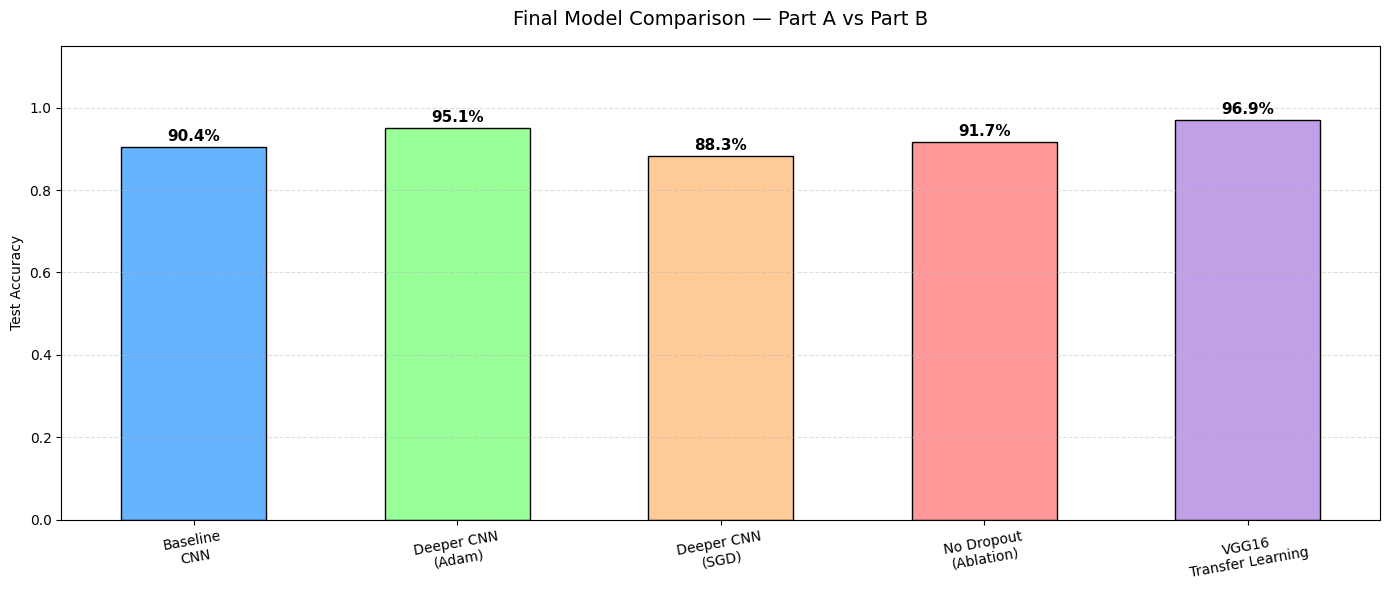

In [ ]:
# ============================================================
# FINAL COMPREHENSIVE COMPARISON — All Models
# ============================================================

all_labels = [
    'Baseline\nCNN',
    'Deeper CNN\n(Adam)',
    'Deeper CNN\n(SGD)',
    'No Dropout\n(Ablation)',
    'VGG16\nTransfer Learning'
]
all_accs  = [baseline_acc, deeper_acc_adam, deeper_acc_sgd, ablation_acc, vgg_acc]
all_times = [
    baseline_time/60,
    deeper_time_adam/60,
    deeper_time_sgd/60,
    ablation_time/60,
    tl_time/60
]

# Print table
print(f"{'Model':<35} {'Accuracy':>12} {'Train Time':>12}")
print('=' * 62)
for name, acc, t in zip(all_labels, all_accs, all_times):
    clean = name.replace('\n', ' ')
    print(f'{clean:<35} {acc*100:>11.2f}%  {t:>8.1f} min')

# Bar chart
colors = ['#66b3ff', '#99ff99', '#ffcc99', '#ff9999', '#c2a0e8']
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(all_labels)), all_accs, color=colors, edgecolor='black', width=0.55)

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2, h + 0.008,
        f'{h*100:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11
    )

ax.set_xticks(range(len(all_labels)))
ax.set_xticklabels(all_labels, rotation=10, ha='center', fontsize=10)
ax.set_title('Final Model Comparison — Part A vs Part B', fontsize=14, pad=15)
ax.set_ylabel('Test Accuracy')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()